Dataset Shape: (1000, 12)

First 5 Rows:
         Date   Location  MinTemp  MaxTemp  Humidity9am  Humidity3pm  \
0  2025-01-01     Mumbai     20.6     28.7           67           37   
1  2025-01-02  New Delhi     29.3     35.8           46           34   
2  2025-01-03     Mumbai     26.0     42.5           74           89   
3  2025-01-04    Kolkata     24.0     39.6           94           38   
4  2025-01-05  New Delhi     17.3     41.1           67           30   

   Pressure9am  Pressure3pm  WindSpeed9am  WindSpeed3pm RainToday RainTomorrow  
0       1001.4       1007.0            10            13        No           No  
1       1008.3       1005.7            10             5        No           No  
2       1009.6        998.9            16            23       Yes          Yes  
3       1010.6       1002.3            16             9        No           No  
4       1005.6        999.4            14            23       Yes           No  

Dataset Information:
<class 'pandas.Dat

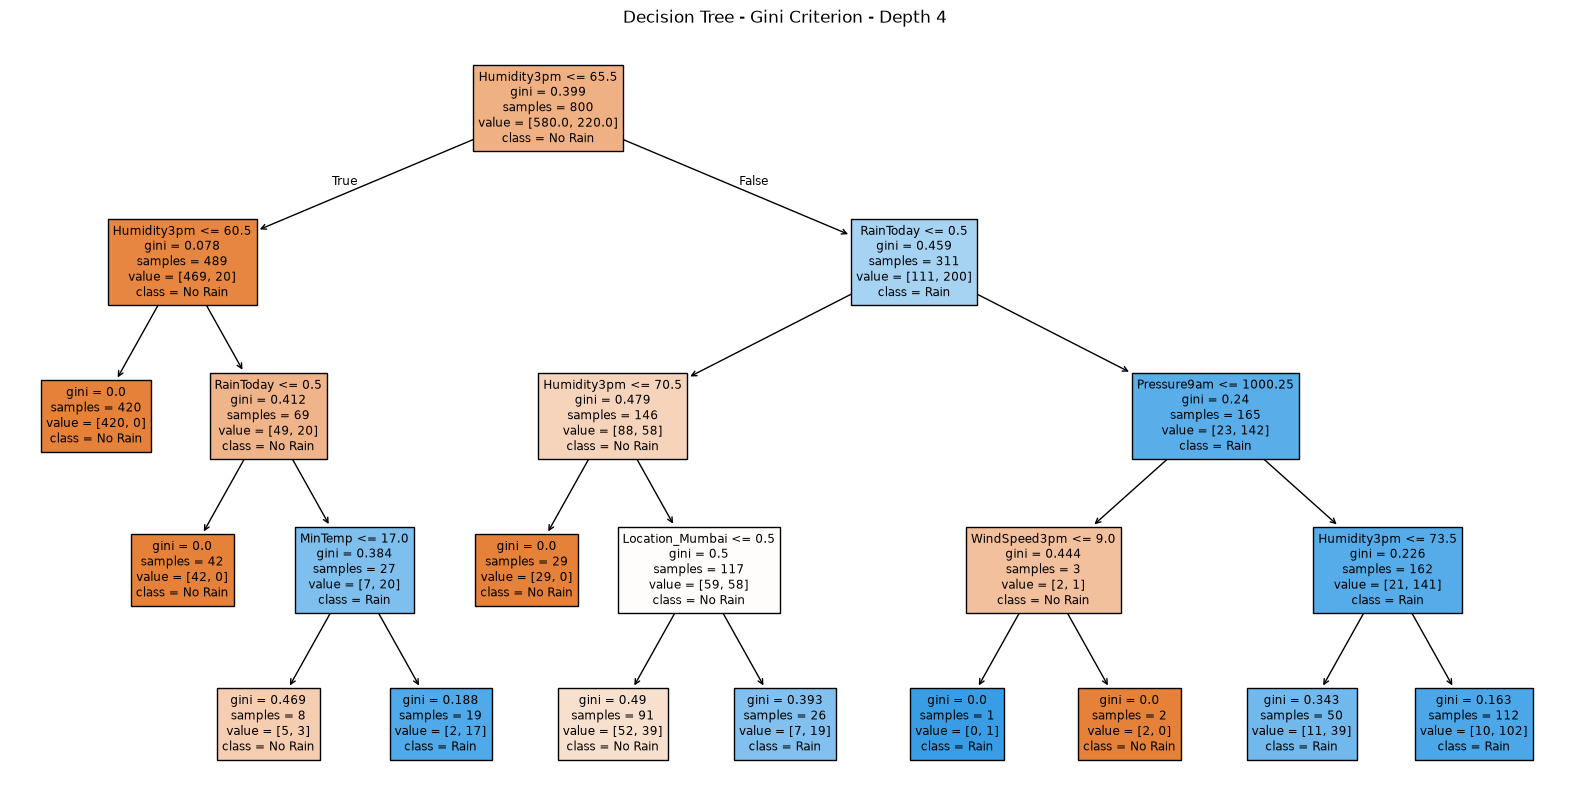

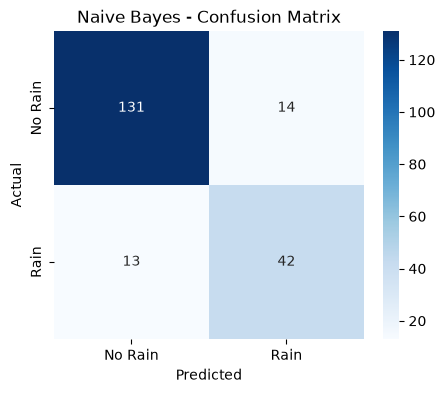

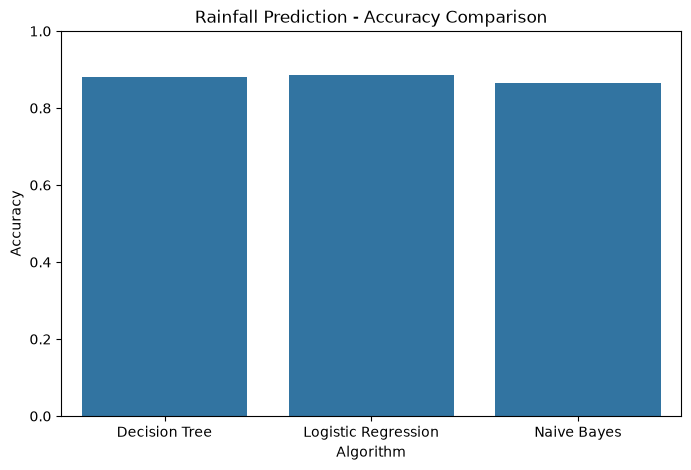


BEST PERFORMING ALGORITHM
Best Algorithm: Decision Tree
Accuracy: 88.0 %
Precision: 0.782
Recall: 0.782
F1 Score: 0.782


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# 1. LOAD DATASET
# ============================================================

df = pd.read_csv("rain_forecasting.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

# ============================================================
# 2. CHECK MISSING VALUES
# ============================================================

print("\nMissing Values:")
print(df.isnull().sum())

# ============================================================
# 3. DATA PREPROCESSING
# ============================================================

# Convert RainToday and RainTomorrow into numerical values

df["RainToday"] = df["RainToday"].map({
    "No": 0,
    "Yes": 1
})

df["RainTomorrow"] = df["RainTomorrow"].map({
    "No": 0,
    "Yes": 1
})

# Convert Location into numerical dummy variables
df = pd.get_dummies(
    df,
    columns=["Location"],
    drop_first=True
)

# Drop Date because it is not directly used as a prediction feature
df = df.drop("Date", axis=1)

print("\nProcessed Dataset:")
print(df.head())

# ============================================================
# 4. DEFINE INPUT AND OUTPUT
# ============================================================

X = df.drop("RainTomorrow", axis=1)
y = df["RainTomorrow"]

print("\nInput Features:")
print(X.columns.tolist())

print("\nTarget Variable: RainTomorrow")

# ============================================================
# 5. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n====================================")
print("TRAIN-TEST SPLIT")
print("====================================")

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

# ============================================================
# 6. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# 7. DECISION TREE
# ============================================================

dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=4,
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

# ============================================================
# 8. LOGISTIC REGRESSION
# ============================================================

lr = LogisticRegression(
    max_iter=1000
)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

# ============================================================
# 9. NAIVE BAYES
# ============================================================

nb = GaussianNB()

nb.fit(X_train_scaled, y_train)

nb_pred = nb.predict(X_test_scaled)

# ============================================================
# 10. DECISION TREE CLASSIFICATION REPORT
# ============================================================

print("\n====================================")
print("DECISION TREE - CLASSIFICATION REPORT")
print("====================================")

print(
    classification_report(
        y_test,
        dt_pred,
        target_names=["No Rain", "Rain"],
        zero_division=0
    )
)

# ============================================================
# 11. LOGISTIC REGRESSION CLASSIFICATION REPORT
# ============================================================

print("\n====================================")
print("LOGISTIC REGRESSION - CLASSIFICATION REPORT")
print("====================================")

print(
    classification_report(
        y_test,
        lr_pred,
        target_names=["No Rain", "Rain"],
        zero_division=0
    )
)

# ============================================================
# 12. NAIVE BAYES CLASSIFICATION REPORT
# ============================================================

print("\n====================================")
print("NAIVE BAYES - CLASSIFICATION REPORT")
print("====================================")

print(
    classification_report(
        y_test,
        nb_pred,
        target_names=["No Rain", "Rain"],
        zero_division=0
    )
)

# ============================================================
# 13. MODEL PERFORMANCE COMPARISON
# ============================================================

results = pd.DataFrame({

    "Algorithm": [
        "Decision Tree",
        "Logistic Regression",
        "Naive Bayes"
    ],

    "Accuracy": [
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, nb_pred)
    ],

    "Precision": [
        precision_score(y_test, dt_pred, zero_division=0),
        precision_score(y_test, lr_pred, zero_division=0),
        precision_score(y_test, nb_pred, zero_division=0)
    ],

    "Recall": [
        recall_score(y_test, dt_pred, zero_division=0),
        recall_score(y_test, lr_pred, zero_division=0),
        recall_score(y_test, nb_pred, zero_division=0)
    ],

    "F1 Score": [
        f1_score(y_test, dt_pred, zero_division=0),
        f1_score(y_test, lr_pred, zero_division=0),
        f1_score(y_test, nb_pred, zero_division=0)
    ]
})

print("\n====================================")
print("MODEL PERFORMANCE COMPARISON")
print("====================================")

print(results.round(3))

# ============================================================
# 14. DECISION TREE VISUALIZATION
# ============================================================

plt.figure(figsize=(20, 10))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["No Rain", "Rain"],
    filled=True,
    max_depth=4
)

plt.title(
    "Decision Tree - Gini Criterion - Depth 4"
)

plt.show()

# ============================================================
# 15. CONFUSION MATRIX - NAIVE BAYES
# ============================================================

cm = confusion_matrix(
    y_test,
    nb_pred
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"]
)

plt.title(
    "Naive Bayes - Confusion Matrix"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ============================================================
# 16. ACCURACY COMPARISON
# ============================================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x="Algorithm",
    y="Accuracy"
)

plt.ylim(0, 1)

plt.title(
    "Rainfall Prediction - Accuracy Comparison"
)

plt.ylabel("Accuracy")

plt.show()

# ============================================================
# 17. FIND BEST ALGORITHM
# ============================================================

best = results.loc[
    results["F1 Score"].idxmax()
]

print("\n====================================")
print("BEST PERFORMING ALGORITHM")
print("====================================")

print(
    "Best Algorithm:",
    best["Algorithm"]
)

print(
    "Accuracy:",
    round(best["Accuracy"] * 100, 2),
    "%"
)

print(
    "Precision:",
    round(best["Precision"], 3)
)

print(
    "Recall:",
    round(best["Recall"], 3)
)

print(
    "F1 Score:",
    round(best["F1 Score"], 3)
)